# SMA crossover vs. buy and hold on SPY

This notebook presents one experiment: a 50/200-day moving-average crossover on SPY, compared with simply buying and holding SPY. It has no logic of its own. Every cell calls tested code in `src/backtester`, the same functions `scripts/run_backtest.py` uses, so the numbers and figures here match the files in `reports/`.

Running it re-runs the experiment from `configs/sma_spy.yaml`. Market data comes from the local cache (downloaded once from Yahoo Finance and checksummed), so reruns are fast and give the same results.

In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from backtester.experiment import format_table, load_config, run_experiment, write_outputs

CONFIG = Path(os.environ.get("BACKTEST_CONFIG", "../configs/sma_spy.yaml"))
experiment = run_experiment(load_config(CONFIG))
figures = write_outputs(experiment)

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


## Setup

- **Data:** daily bars, adjusted for splits and dividends, so returns include reinvested dividends.
- **Timing:** each decision uses only data up to that day's close and trades at the next day's open. The test suite checks that no decision can see the future.
- **Costs:** none. Results are before commissions, spreads, and slippage.
- **Sizing:** fractional shares, either fully invested or fully in cash. No leverage, no shorting.

In [2]:
config = experiment.config
start, end = experiment.window
data = experiment.data
pd.Series(
    {
        "Symbol": config.symbol,
        "Data": f"{data.start:%Y-%m-%d} to {data.end:%Y-%m-%d} ({len(data):,} trading days)",
        "Crossover": f"{config.fast}-day vs. {config.slow}-day simple moving average",
        "Crossover's first decision": experiment.strategy.config["first_decision"],
        "Comparison window": f"{start:%Y-%m-%d} to {end:%Y-%m-%d}",
        "Starting cash": f"${config.initial_cash:,.0f}",
        "Execution": experiment.strategy.config["execution"],
    },
    name="",
).to_frame()

,
Symbol,SPY
Data,"2004-01-02 to 2024-12-31 (5,285 trading days)"
Crossover,50-day vs. 200-day simple moving average
Crossover's first decision,2004-10-18
Comparison window,2004-10-18 to 2024-12-31
Starting cash,"$100,000"
Execution,NextOpenExecution(cost_model=ZeroCost())


## Headline comparison

Both strategies are measured over the same window. It starts on the crossover's first decision date: the crossover needs 200 days of history before it can act, and buy and hold shouldn't be credited with gains made during that warmup. `ending_value` is what the starting cash, invested on that date, grew to.

- `total_return` and `cagr` (compound annual growth rate) measure growth.
- `annualized_vol` and `sharpe` (average return per unit of volatility, annualized, with a 0% risk-free rate) measure how bumpy the ride was.
- `max_drawdown` is the largest fall from a previous high, with the dates it began and bottomed out.
- `exposure` is the share of days with money in the market, and `n_fills` the number of trades.

In [3]:
format_table(experiment.comparison(), experiment.labels).T

,SMA crossover (50/200),Buy and hold
start,2004-10-18,2004-10-18
end,2024-12-31,2024-12-31
periods,5085,5085
total_return,486.6%,670.5%
cagr,9.2%,10.6%
annualized_vol,13.5%,19.0%
sharpe,0.72,0.63
max_drawdown,-33.7%,-55.2%
max_drawdown_peak,2020-02-19,2007-10-09
max_drawdown_trough,2020-03-23,2009-03-09


## Equity curves

Both curves start from the same value on the same day. The scale is logarithmic, so equal vertical distances mean equal percentage moves. Flat stretches in the crossover's curve are periods in cash. Where the lines pull apart is where the strategy's timing made a difference, in either direction.

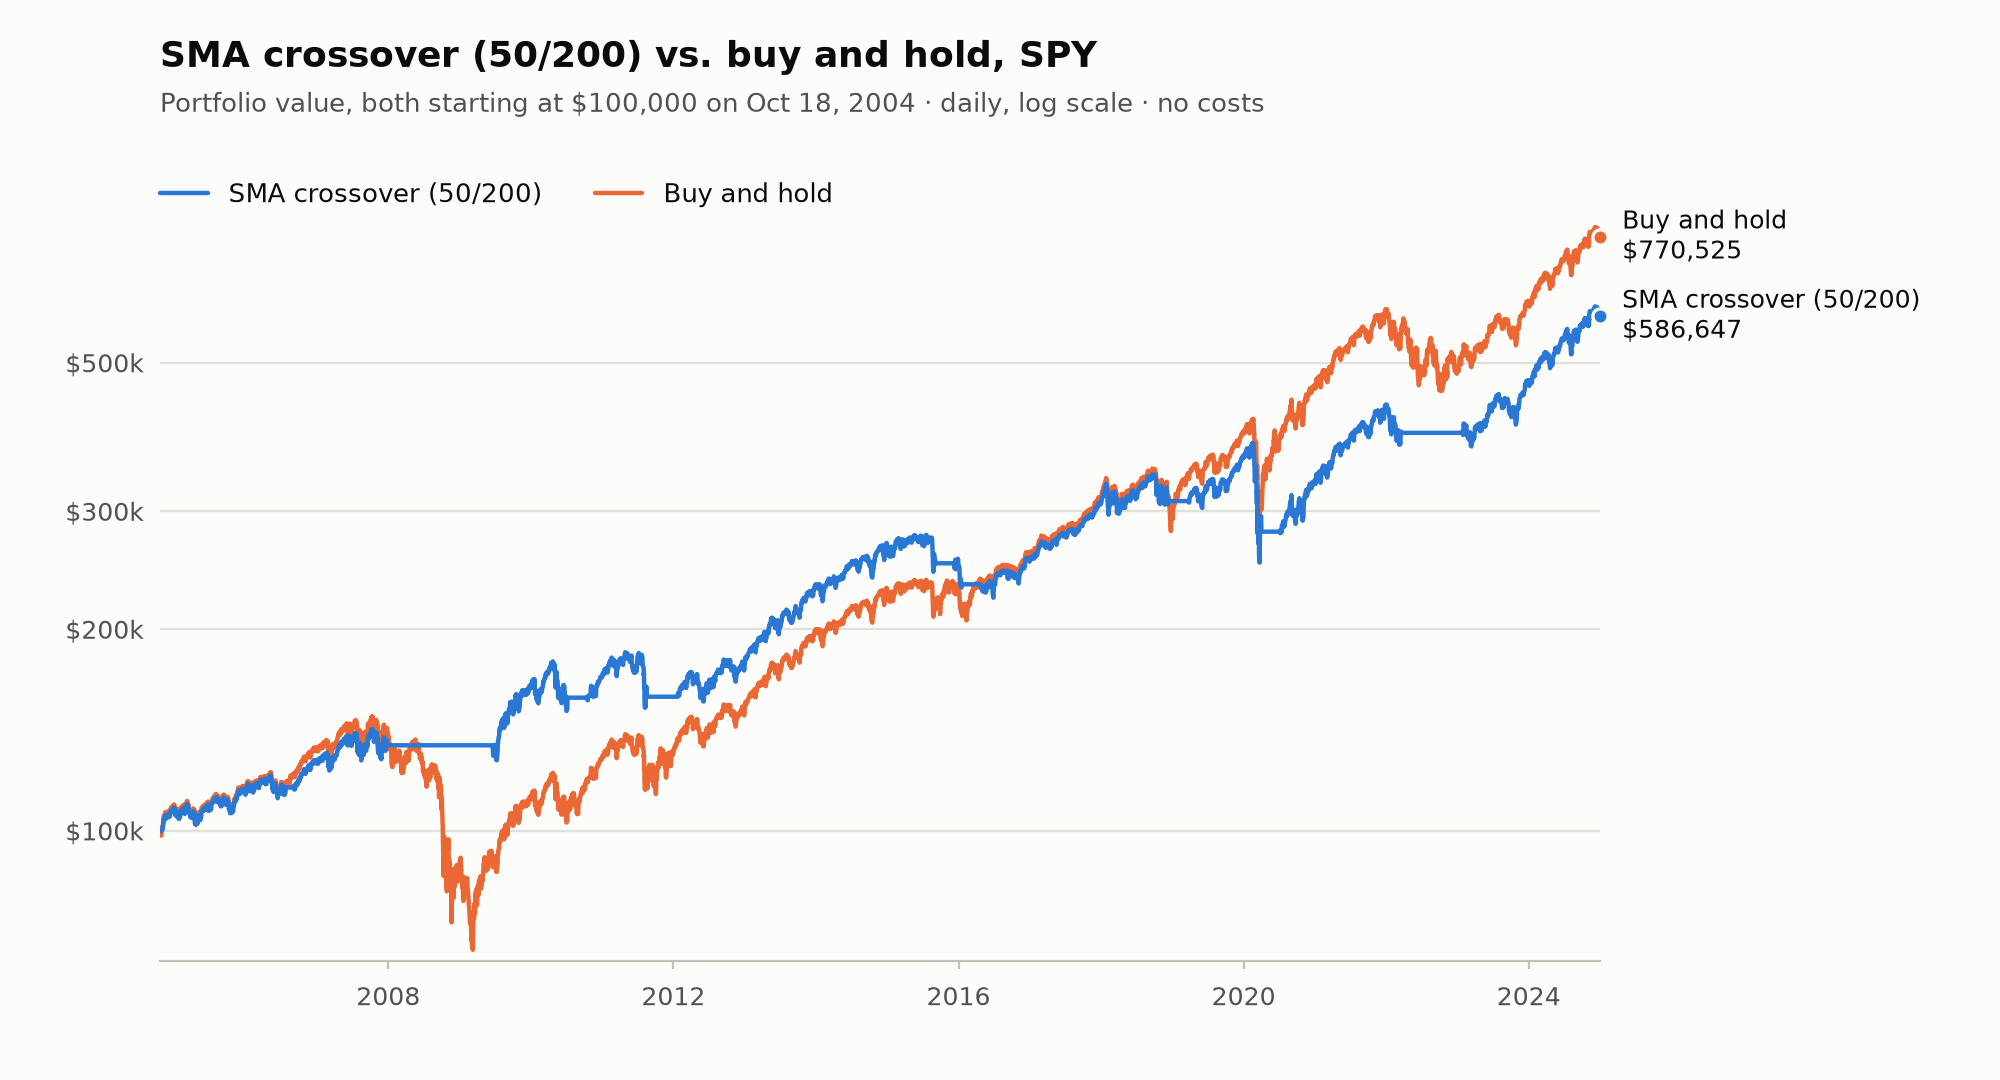

In [4]:
display(Image(figures["equity"]))

## Drawdowns

A drawdown is how far the portfolio sits below its highest value so far. Trend-following rules like this crossover typically give up some upside in exchange for shallower drawdowns: they exit after a decline is already under way and re-enter after a recovery has started. This chart shows whether that trade-off happened here.

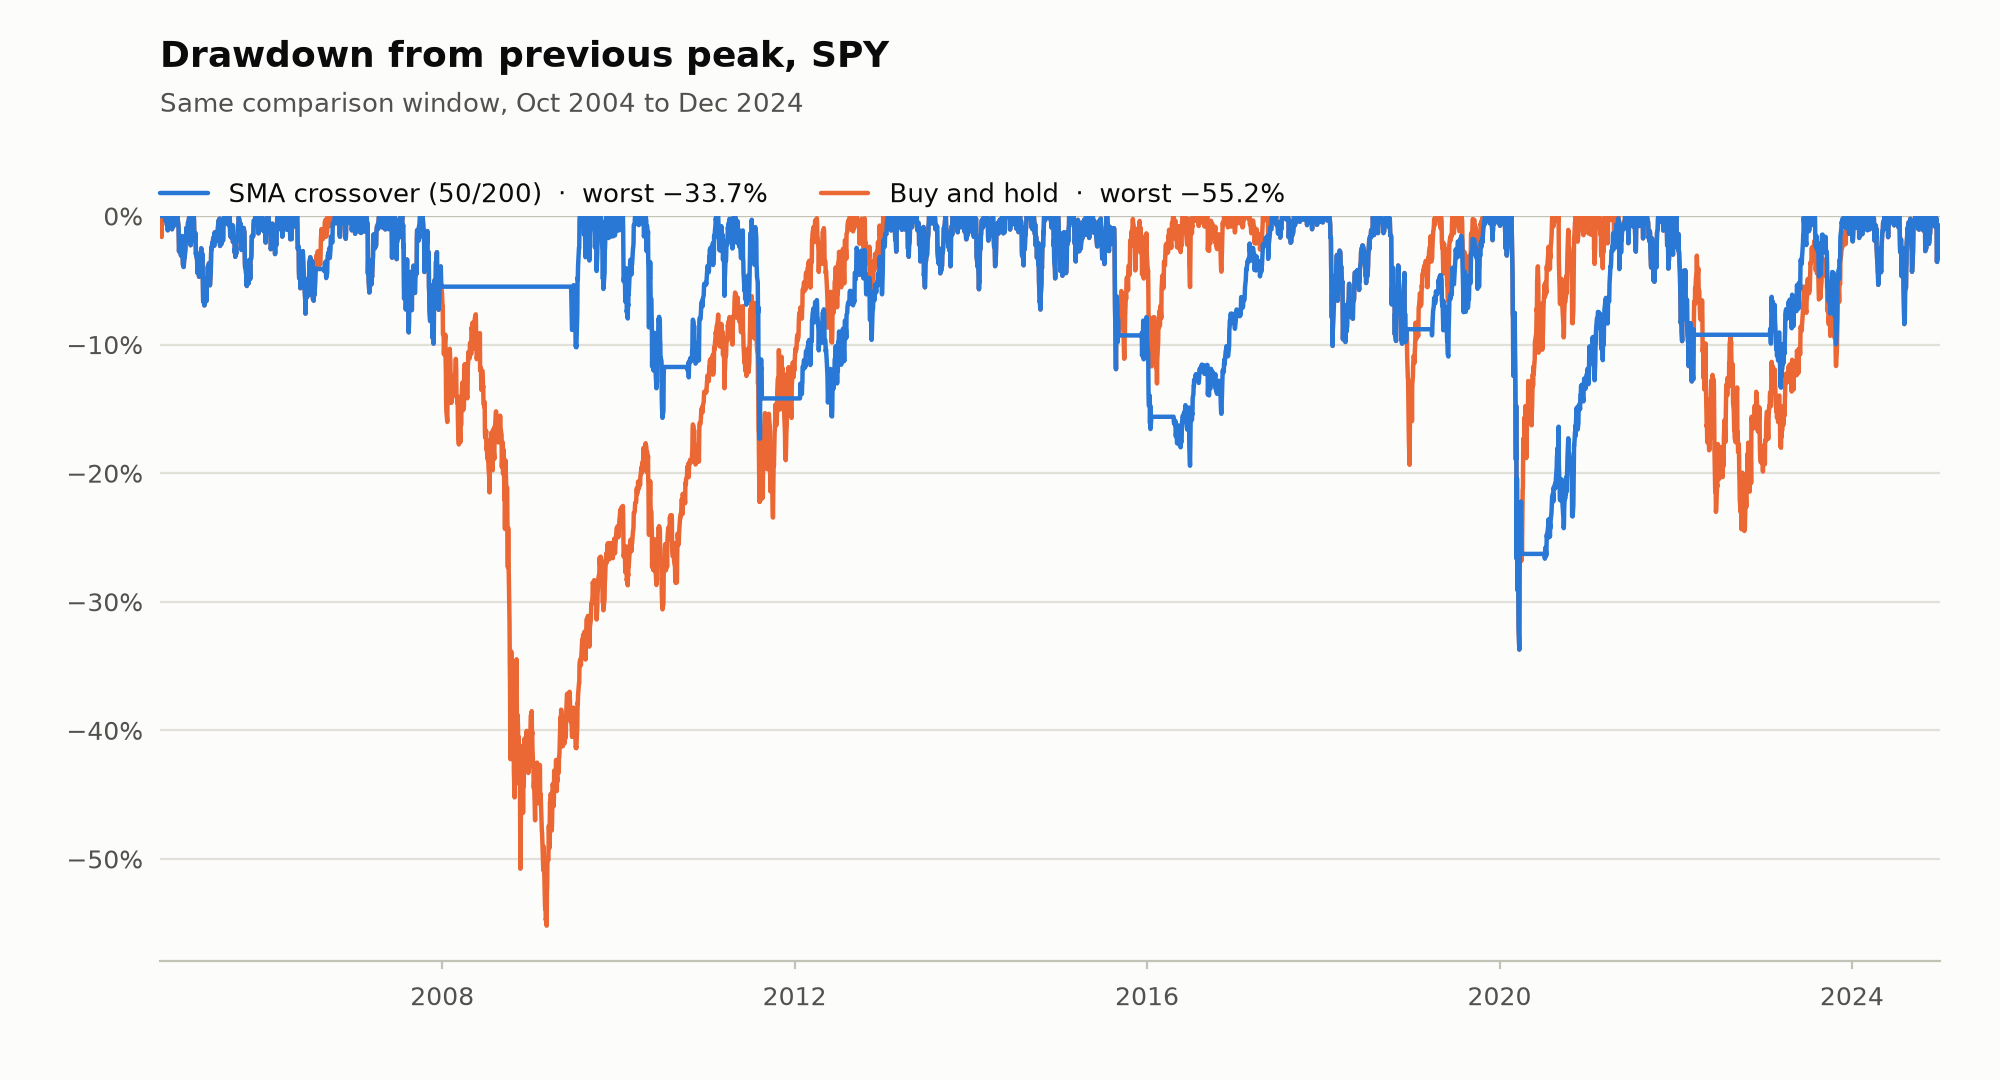

In [5]:
display(Image(figures["drawdown"]))

## When the crossover is in the market

Shaded bands are the periods when the strategy held a position. A band starts at the open after the 50-day average closes above the 200-day average, and ends at the open after it closes back below.

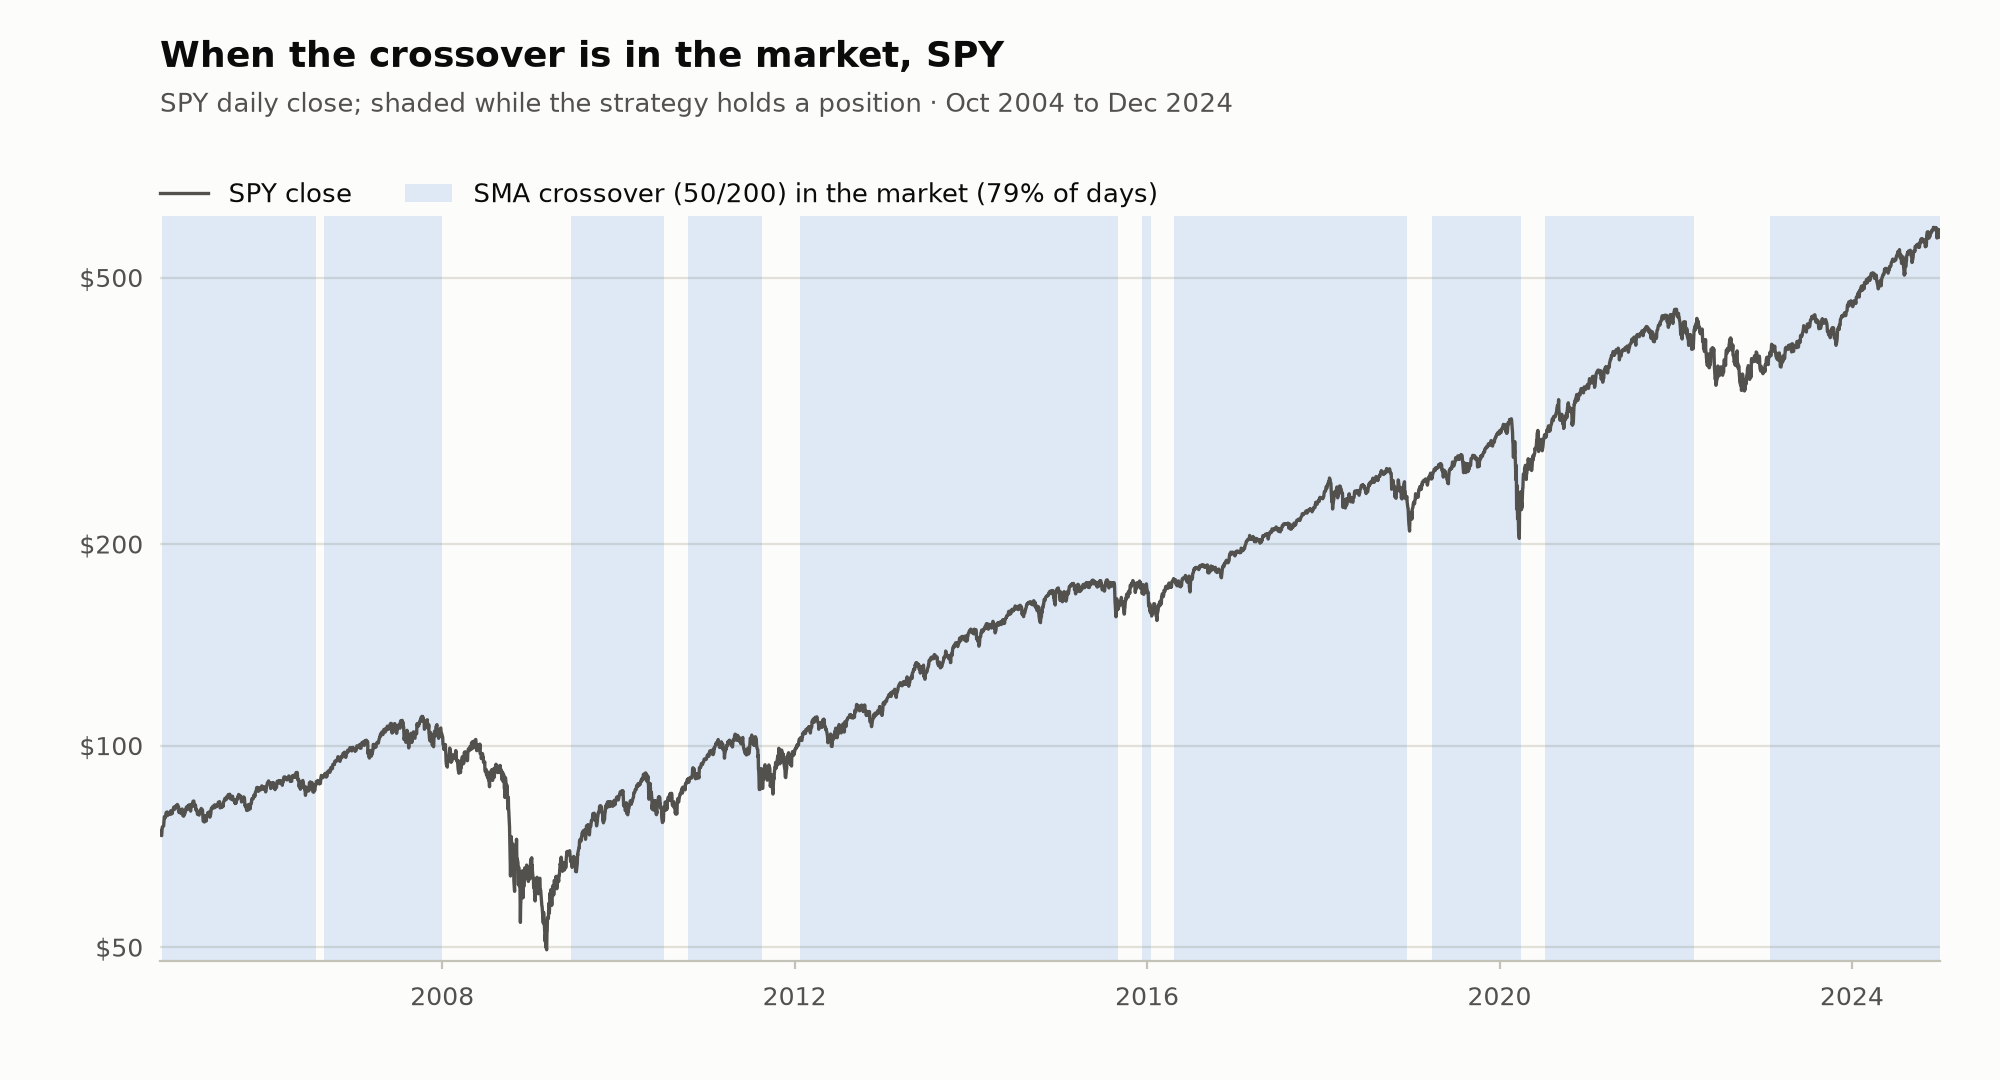

In [6]:
display(Image(figures["positions"]))

## Each strategy on its own

This table measures each strategy from its own first decision: buy and hold from the first day of data, the crossover from the end of its warmup. That describes each strategy alone, but the windows differ, so use the headline comparison above to compare them.

In [7]:
format_table(experiment.standalone(), experiment.labels).T

,SMA crossover (50/200),Buy and hold
start,2004-10-18,2004-01-02
end,2024-12-31,2024-12-31
periods,5085,5284
total_return,486.6%,679.2%
cagr,9.2%,10.3%
annualized_vol,13.5%,18.7%
sharpe,0.72,0.62
max_drawdown,-33.7%,-55.2%
max_drawdown_peak,2020-02-19,2007-10-09
max_drawdown_trough,2020-03-23,2009-03-09


## What this does and doesn't show

- **One asset, one period, fixed parameters.** 50/200 is the conventional pair, chosen in advance rather than tuned on this data. This is a transparent baseline, not evidence of an edge.
- **No transaction costs.** The crossover trades many more times than buy and hold (see `n_fills`), so costs would reduce its results more.
- **Dividends are included** through adjusted prices. Taxes are not.
- **The comparison starts at a close.** Buy and hold is already invested at that close, while the crossover trades at the next open, so the benchmark also gets the first overnight move. That is one day out of the whole window.